# Task 26 -- Introduction to Transformers & the Attention Mechanism (Conceptual)
**PKCERT AI & Software Development Internship**
Author: Abdullah Amir

This task is explicitly conceptual (per the brief): no attention mechanism or
Transformer block is implemented from scratch as a trainable component.
Parts A/B derive scaled dot-product attention, multi-head attention,
sinusoidal positional encoding, and the encoder/decoder architecture from
first principles, with small illustrative NumPy demonstrations (a worked
attention example, a positional-encoding visualization, architecture
diagrams) rather than a production implementation. Part C applies a
pretrained DistilBERT (via Hugging Face `transformers`) to text
classification on AG News -- the *identical* train/val/test split used in
Task 25 -- for a genuine, apples-to-apples LSTM-vs-Transformer comparison.
Part D documents the pipeline, findings, challenges, and reflects on
Transformer limitations.

Part C ran as a standalone script (DistilBERT fine-tuning, 3 epochs) so it
could execute unattended; this notebook re-displays its actual saved
results rather than retraining.

In [1]:
import json
from pathlib import Path
from IPython.display import Image, display
import warnings
warnings.filterwarnings("ignore")

RESULTS = Path("results")
FIGURES = Path("figures")

def show(name):
    display(Image(filename=str(FIGURES / name)))

def load(name):
    return json.loads((RESULTS / name).read_text())

---
## Part A -- From Recurrence to Attention (20 marks)

In [2]:
"""
Shared utilities for Task 26 (Transformers & Attention -- Applied Part C):
AG News loading/subsetting and evaluation helpers.

The train/val/test subsetting logic (seed, per-class sizes, class-balanced
selection algorithm) is deliberately an exact copy of Task 25's common.py --
same AG News dataset revision, same seed=42, same algorithm, so the
resulting train/val/test *examples* are identical between the two tasks.
This is what makes the Part C LSTM-vs-Transformer comparison a genuine
apples-to-apples one rather than merely "a similar dataset."

Seed 42 throughout, CPU only (no CUDA device available in this environment).
"""
import json
import random
from pathlib import Path

import numpy as np
import torch

SEED = 42
ROOT = Path(__file__).parent if "__file__" in globals() else Path.cwd()
DATA_DIR = ROOT / "data"
MODELS_DIR = ROOT / "models"
RESULTS_DIR = ROOT / "results"
FIGURES_DIR = ROOT / "figures"
for d in (DATA_DIR, MODELS_DIR, RESULTS_DIR, FIGURES_DIR):
    d.mkdir(exist_ok=True)

AG_NEWS_CLASSES = ["World", "Sports", "Business", "Sci/Tech"]

# Identical to Task 25's common.py -- see module docstring.
N_TRAIN = 12000
N_VAL = 2000
N_TEST = 2000


def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


def get_raw_ag_news():
    from datasets import load_dataset
    ds = load_dataset("fancyzhx/ag_news")
    return ds["train"], ds["test"]


def _class_balanced_indices(labels, n_per_class, n_classes, seed=SEED):
    rng = np.random.RandomState(seed)
    labels = np.array(labels)
    chosen = []
    for c in range(n_classes):
        idx = np.where(labels == c)[0]
        rng.shuffle(idx)
        chosen.append(idx[:n_per_class])
    idx = np.concatenate(chosen)
    rng.shuffle(idx)
    return idx.tolist()


def build_split_indices():
    """Byte-for-byte the same algorithm as Task 25's build_split_indices --
    reproduces the identical train/val/test example indices given the same
    AG News dataset revision, so results are directly comparable."""
    cache = RESULTS_DIR / "split_indices.json"
    if cache.exists():
        return json.loads(cache.read_text())

    train_full, test_full = get_raw_ag_news()
    train_labels = np.array(train_full["label"])
    n_classes = len(AG_NEWS_CLASSES)

    train_idx, val_idx = [], []
    rng = np.random.RandomState(SEED)
    n_train_per_class = N_TRAIN // n_classes
    n_val_per_class = N_VAL // n_classes
    for c in range(n_classes):
        idx = np.where(train_labels == c)[0]
        rng.shuffle(idx)
        train_idx.extend(idx[:n_train_per_class].tolist())
        val_idx.extend(idx[n_train_per_class:n_train_per_class + n_val_per_class].tolist())

    test_idx = _class_balanced_indices(test_full["label"], N_TEST // n_classes, n_classes, seed=SEED)

    out = dict(train_idx=train_idx, val_idx=val_idx, test_idx=test_idx)
    cache.write_text(json.dumps(out))
    return out


def get_text_splits():
    """Returns (train_texts, train_labels, val_texts, val_labels, test_texts, test_labels)."""
    train_full, test_full = get_raw_ag_news()
    idx = build_split_indices()
    train_texts = [train_full[i]["text"] for i in idx["train_idx"]]
    train_labels = [train_full[i]["label"] for i in idx["train_idx"]]
    val_texts = [train_full[i]["text"] for i in idx["val_idx"]]
    val_labels = [train_full[i]["label"] for i in idx["val_idx"]]
    test_texts = [test_full[i]["text"] for i in idx["test_idx"]]
    test_labels = [test_full[i]["label"] for i in idx["test_idx"]]
    return train_texts, train_labels, val_texts, val_labels, test_texts, test_labels


def save_json(obj, path):
    Path(path).write_text(json.dumps(obj, indent=2))


def load_json(path):
    return json.loads(Path(path).read_text())


In [3]:
"""
Task 26, Part A -- From Recurrence to Attention (20 marks)

This task is explicitly conceptual: no attention mechanism or Transformer
block is implemented from scratch as a trainable component. The NumPy code
below is exactly what the brief itself asks for in A4 -- "a worked numerical
example on a short toy sequence... how attention weights are computed" --
a hand-computed pedagogical illustration on 4 fixed, hand-chosen vectors,
not a general-purpose or trainable attention module.
"""
import json

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from common import FIGURES_DIR, RESULTS_DIR, set_seed

# ============================================================================
# A1 -- structural bottlenecks of recurrent architectures
# ============================================================================
A1_DISCUSSION = """
A1 -- Structural bottlenecks of recurrent architectures (referencing Task 25)
----------------------------------------------------------------------------------
Task 25 derived and empirically measured three specific bottlenecks that motivate
attention as a replacement, not merely an addition, for recurrence:

1. **Sequential computation.** The RNN/LSTM recurrence h_t = f(x_t, h_{t-1})
   (Task 25 Part A2) makes step t's computation depend on step t-1's output
   by construction -- there is no way to compute h_5 before h_4 exists. This
   forces strictly sequential processing with no parallelism across the time
   dimension, regardless of available compute. Task 25's own timing numbers
   reflect this: LSTM training scaled with epochs x sequence length x batches
   processed one step at a time internally, even on a 12-core CPU.

2. **Long-range dependency decay.** Task 25 Part A's vanishing-gradient demo
   measured this precisely, not just asserted it: a Jacobian-product norm
   through BPTT collapsed to ~1.17x10^-18 after 60 steps at spectral radius
   0.5, and Task 25 Part B showed the LSTM's cell-state highway (forget-gate
   product) *mitigates* but does not eliminate this -- gradient signal from
   distant tokens is still systematically the smallest term in dL/dW_hh's
   sum over time steps (Task 25 Part A3/A4). Practically: information from
   token 1 must survive being compressed through many sequential gated
   updates to influence token 50's prediction.

3. **Fixed-size context propagation.** Whether it's a vanilla RNN's h_t or an
   LSTM's (h_t, c_t) pair, the *entire* history up to step t is compressed
   into one fixed-dimensionality vector (or two), regardless of how many
   tokens have been seen. A 500-token document and a 5-token sentence are
   both forced through the same H-dimensional bottleneck -- capacity does
   not grow with sequence length, so longer sequences necessarily lose more
   information per token to this compression.

Attention directly targets all three: it lets every output position access
every input position through an unbroken, non-recurrent computation (fixing
#1's sequential constraint and #2's decay, since the "path length" between
any two positions becomes O(1) instead of O(distance)), and it replaces the
fixed-size bottleneck with a weighted combination over *all* input positions'
own representations, not one compressed summary (fixing #3).
""".strip()


# ============================================================================
# A2 -- Bahdanau/Luong attention for encoder-decoder RNNs
# ============================================================================
A2_DISCUSSION = r"""
A2 -- Attention for encoder-decoder RNNs (Bahdanau / Luong)
---------------------------------------------------------------
Setup: an encoder RNN produces one hidden state h_i for every source
position i = 1..T_x. A decoder RNN, generating output token t, has its own
hidden state s_{t-1} (or s_t, depending on the variant) from the previous
decoder step. Instead of forcing the decoder to rely on a single fixed
encoder summary vector (the pre-attention seq2seq bottleneck -- exactly
A1's bottleneck #3), attention lets the decoder look back at *every*
encoder hidden state at every decoder step, weighted by relevance.

**Alignment score** e_{t,i} -- how well encoder position i matches decoder
step t:
  Bahdanau (additive):    e_{t,i} = v^T tanh(W_a s_{t-1} + U_a h_i)
  Luong (multiplicative):
      dot:      e_{t,i} = s_t^T h_i
      general:  e_{t,i} = s_t^T W_a h_i

**Attention weights** -- normalize the T_x alignment scores for decoder step
t into a probability distribution over source positions:
  alpha_{t,i} = exp(e_{t,i}) / sum_{j=1}^{T_x} exp(e_{t,j})

**Context vector** -- the weighted sum of encoder states this distribution
defines:
  c_t = sum_{i=1}^{T_x} alpha_{t,i} h_i

c_t is then concatenated with (Luong) or used to compute (Bahdanau) the
decoder's next hidden state / output, giving the decoder direct, weighted
access to the *entire* encoder sequence at every single decoding step --
this is the mechanism scaled dot-product attention (A3) generalizes and
makes efficiently batchable via matrix multiplication.
""".strip()


# ============================================================================
# A3 -- scaled dot-product attention, derived
# ============================================================================
A3_DERIVATION = r"""
A3 -- Scaled dot-product attention, derived
------------------------------------------------
    Attention(Q, K, V) = softmax(QK^T / sqrt(d_k)) V

**Q, K, V -- role and dimensionality.** For n_q query positions and n_k
key/value positions: Q in R^{n_q x d_k} (one d_k-dim query vector per query
position -- "what am I looking for"), K in R^{n_k x d_k} (one d_k-dim key
per key/value position -- "what do I contain, for matching purposes"),
V in R^{n_k x d_v} (one d_v-dim value per position -- "what do I actually
contribute if attended to"; d_v need not equal d_k). This directly
generalizes A2's alignment mechanism: QK^T (shape n_q x n_k) is exactly a
batched, matrix-multiply version of every alignment score e_{t,i} computed
at once (dot-product/Luong-style, applied to *learned linear projections*
of the underlying representations rather than the raw hidden states
themselves) instead of one RNN decoder step's score against one encoder
state at a time.

**Step by step**:
  1. S = QK^T                 (n_q x n_k)  raw similarity scores
  2. S' = S / sqrt(d_k)       (n_q x n_k)  scaled scores (justified below)
  3. A = softmax(S', axis=-1) (n_q x n_k)  each row sums to 1 -- attention
                                            weights, generalizing A2's alpha
  4. Attention(Q,K,V) = A V   (n_q x d_v)  weighted combination of value
                                            vectors, generalizing A2's c_t

**Why 1/sqrt(d_k) is necessary.** Assume Q and K's entries are i.i.d. with
mean 0 and variance 1 (a standard initialization assumption). For a single
dot product q . k = sum_{i=1}^{d_k} q_i k_i, each term q_i k_i has mean 0 and
variance 1 (product of two independent unit-variance, zero-mean variables),
so by independence across the d_k terms:
    Var(q . k) = sum_{i=1}^{d_k} Var(q_i k_i) = d_k

So the *unscaled* dot product's standard deviation grows as sqrt(d_k) --
for a typical Transformer d_k (e.g. 64), raw scores can easily reach
magnitudes of +-20 or more. Softmax's gradient is
    d(softmax(x)_i)/dx_j = softmax(x)_i (delta_ij - softmax(x)_j)
which vanishes whenever softmax(x) saturates toward a one-hot vector (any
p_i near 0 or 1) -- exactly what happens when its inputs have large
magnitude, since softmax is scale-sensitive (softmax(c*x) sharpens toward
one-hot as c grows). Dividing by sqrt(d_k) rescales q.k back to unit
variance *independent of d_k*, keeping softmax's input distribution
well-conditioned regardless of how large the projection dimension is --
directly the same saturating-nonlinearity-plus-large-preactivation
gradient-vanishing mechanism Task 25 Part A/B analyzed for tanh/sigmoid,
just occurring inside softmax instead.
""".strip()


# ============================================================================
# A4 -- worked numerical example
# ============================================================================
def worked_example():
    """4 toy tokens, d_k=d_v=3, hand-chosen so token 3 ('bank') is
    deliberately constructed to be most similar (in Q/K space) to token 1
    ('river'), illustrating disambiguation-by-context: the query for 'bank'
    ends up attending most strongly to 'river', pulling 'river'-like
    information into bank's context vector -- the toy version of what a
    real self-attention layer does for word-sense disambiguation."""
    tokens = ["river", "flows", "bank", "money"]
    # Key vectors: 'river' and 'bank' share a "geography" component (dim 0);
    # 'money' has a "finance" component (dim 2) that 'bank' also partially shares.
    K = np.array([
        [1.0, 0.0, 0.0],   # river  -- geography
        [0.2, 1.0, 0.0],   # flows  -- action, weakly geography-linked
        [0.6, 0.0, 0.5],   # bank   -- ambiguous: geography + finance
        [0.0, 0.0, 1.0],   # money  -- finance
    ])
    V = np.array([
        [1.0, 0.0, 0.0],
        [0.0, 1.0, 0.0],
        [0.0, 0.0, 1.0],
        [0.5, 0.5, 0.5],
    ])
    # Query: we're computing the *contextualized* representation of "bank"
    # (query = bank's own vector, self-attention style), which is
    # deliberately close to river's key (geography-leaning query).
    Q_bank = np.array([0.9, 0.0, 0.1])

    d_k = K.shape[1]
    scores = Q_bank @ K.T                      # raw dot-product scores, shape (4,)
    scaled_scores = scores / np.sqrt(d_k)       # scaling (A3)
    exp_scores = np.exp(scaled_scores - scaled_scores.max())  # numerically stable softmax
    weights = exp_scores / exp_scores.sum()
    context = weights @ V                        # shape (3,)

    result = dict(
        tokens=tokens,
        raw_scores=scores.tolist(),
        scaled_scores=scaled_scores.tolist(),
        attention_weights=weights.tolist(),
        context_vector=context.tolist(),
    )
    print("Worked example: computing the contextualized representation of the query token 'bank'")
    print(f"  d_k = {d_k}")
    for i, t in enumerate(tokens):
        print(f"  key/value {i} ({t:6s}): raw_score={scores[i]:+.3f}  "
              f"scaled_score={scaled_scores[i]:+.3f}  attention_weight={weights[i]:.4f}")
    print(f"  context vector for 'bank' = {np.round(context, 4).tolist()}")
    top = tokens[int(np.argmax(weights))]
    print(f"  Highest-attended token: '{top}' (weight={weights.max():.4f}) -- 'bank' most strongly "
          f"attends to '{top}', pulling its geography-flavored value vector into bank's own "
          f"contextualized representation. This is the toy mechanism behind word-sense "
          f"disambiguation: the *same* embedding for 'bank' ends up with a different "
          f"contextualized representation depending on which other tokens are present "
          f"in the sequence and how similar their keys are to bank's query.")

    fig, ax = plt.subplots(figsize=(6, 4))
    colors = ["#4C72B0" if t != top else "#DD8452" for t in tokens]
    ax.bar(tokens, weights, color=colors)
    ax.set_ylabel("attention weight")
    ax.set_title("Worked example: attention weights for query token 'bank'")
    for i, w in enumerate(weights):
        ax.text(i, w + 0.01, f"{w:.3f}", ha="center", fontsize=10)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_a_worked_example.png", dpi=130)
    plt.close(fig)

    return result


def main():
    set_seed(42)
    print(A1_DISCUSSION)
    print("\n" + A2_DISCUSSION)
    print("\n" + A3_DERIVATION)

    print("\n--- A4: worked numerical example ---")
    result = worked_example()

    with open(RESULTS_DIR / "part_a_results.json", "w") as f:
        json.dump(result, f, indent=2)
    print("\nPart A complete.")


### Part A: run the derivations and worked example

In [4]:
set_seed(42)
print(A1_DISCUSSION)
print()
print(A2_DISCUSSION)
print()
print(A3_DERIVATION)

A1 -- Structural bottlenecks of recurrent architectures (referencing Task 25)
----------------------------------------------------------------------------------
Task 25 derived and empirically measured three specific bottlenecks that motivate
attention as a replacement, not merely an addition, for recurrence:

1. **Sequential computation.** The RNN/LSTM recurrence h_t = f(x_t, h_{t-1})
   (Task 25 Part A2) makes step t's computation depend on step t-1's output
   by construction -- there is no way to compute h_5 before h_4 exists. This
   forces strictly sequential processing with no parallelism across the time
   dimension, regardless of available compute. Task 25's own timing numbers
   reflect this: LSTM training scaled with epochs x sequence length x batches
   processed one step at a time internally, even on a 12-core CPU.

2. **Long-range dependency decay.** Task 25 Part A's vanishing-gradient demo
   measured this precisely, not just asserted it: a Jacobian-product norm
   throu

In [5]:
result = worked_example()

Worked example: computing the contextualized representation of the query token 'bank'
  d_k = 3
  key/value 0 (river ): raw_score=+0.900  scaled_score=+0.520  attention_weight=0.3199
  key/value 1 (flows ): raw_score=+0.180  scaled_score=+0.104  attention_weight=0.2111
  key/value 2 (bank  ): raw_score=+0.590  scaled_score=+0.341  attention_weight=0.2675
  key/value 3 (money ): raw_score=+0.100  scaled_score=+0.058  attention_weight=0.2016
  context vector for 'bank' = [0.4207, 0.3119, 0.3682]
  Highest-attended token: 'river' (weight=0.3199) -- 'bank' most strongly attends to 'river', pulling its geography-flavored value vector into bank's own contextualized representation. This is the toy mechanism behind word-sense disambiguation: the *same* embedding for 'bank' ends up with a different contextualized representation depending on which other tokens are present in the sequence and how similar their keys are to bank's query.


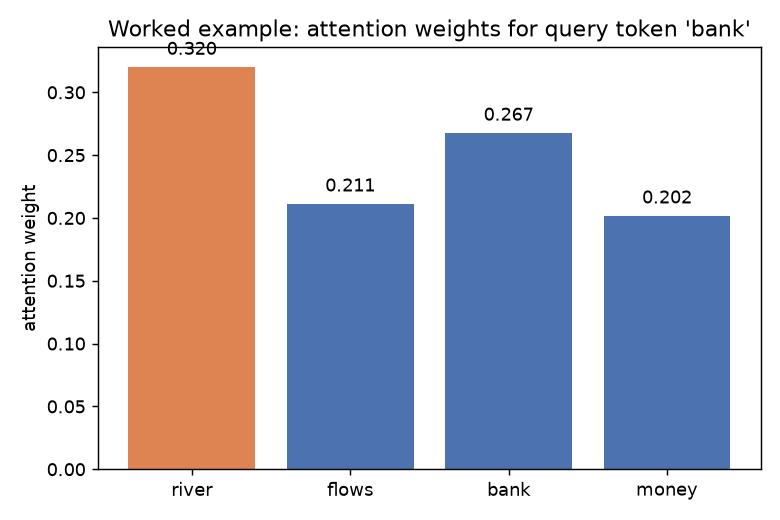

In [6]:
show("part_a_worked_example.png")

---
## Part B -- Transformer Architecture (25 marks)

In [7]:
"""
Task 26, Part B -- Transformer Architecture (25 marks)

Conceptual, per the brief -- no Transformer block implemented from scratch.
The NumPy code below computes and visualizes the sinusoidal positional
encoding formula (explicitly requested: "derive the sinusoidal positional
encoding formulation") and a complexity-comparison curve, plus two
matplotlib architecture diagrams (encoder/decoder blocks) -- illustrative
tooling, not a trainable attention/Transformer implementation.
"""
import json

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from common import FIGURES_DIR, RESULTS_DIR, set_seed

# ============================================================================
# B1 -- multi-head attention
# ============================================================================
B1_DISCUSSION = r"""
B1 -- Multi-head attention, formally
------------------------------------------
**Why multiple heads instead of one.** A single attention computation
produces exactly one weighted average per query position -- one attention
distribution over all key positions, computed in one subspace. If two
different tokens are relevant to a given query for two *different* reasons
(e.g. one because of a syntactic dependency, another because of coreference),
a single head is forced to blend both signals into one shared weighting,
which can wash out either pattern. Multiple heads run several attention
computations in parallel, each in its own learned, lower-dimensional
subspace, letting different heads specialize in different relational
patterns without one head's weighting decision interfering with another's.

**Splitting and concatenation.** For model dimension d_model and h heads
(so d_k = d_v = d_model / h), each head i gets its own learned projections
W_i^Q, W_i^K in R^{d_model x d_k}, W_i^V in R^{d_model x d_v}:
    head_i = Attention(Q W_i^Q,  K W_i^K,  V W_i^V)      each head_i in R^{n x d_v}
    MultiHead(Q,K,V) = Concat(head_1, ..., head_h) W^O    W^O in R^{d_model x d_model}
The h heads' outputs (each n x d_v) are concatenated along the feature axis
back to n x d_model, then linearly mixed by W^O so information from
different heads' subspaces can combine before the next layer.

**Empirically observed complementary patterns** (documented in attention-
analysis work on trained Transformers, e.g. Clark et al. 2019 "What Does
BERT Look At?"): some heads attend almost entirely to the immediately
adjacent token (local/positional patterns), some attend to specific
syntactic relations (e.g. a verb attending to its direct object, or a noun
attending to its determiner), some attend to coreference-like patterns
(a pronoun attending back to its antecedent), and some attend broadly/near-
uniformly across the whole sequence (functioning closer to a
bag-of-words/global-context signal) or heavily to special tokens like
[CLS]/[SEP]. No single pattern is hand-designed into any head -- these
specializations emerge purely from gradient descent on the pretraining
objective, and different heads within the same layer routinely specialize
in visibly different patterns, which is the empirical justification for
using several heads rather than one.
""".strip()


# ============================================================================
# B2 -- positional encoding
# ============================================================================
B2_DISCUSSION = r"""
B2 -- Why Transformers lack inherent token order, and sinusoidal positional encoding
-----------------------------------------------------------------------------------------
**No inherent order.** Self-attention, Attention(Q,K,V) = softmax(QK^T/sqrt(d_k))V,
is a function of the *set* of input vectors, not their sequence positions --
there is no term anywhere in the computation that depends on a position
index t. Permuting the rows of Q, K, V permutes the output rows
correspondingly (the operation is permutation-*equivariant*), but the actual
values computed for any given token are identical regardless of where else
in the sequence it sits, as long as the *set* of other tokens is unchanged.
Contrast the RNN (Task 25 Part A2): h_t = f(x_t, h_{t-1}) is order-dependent
by construction, since h_{t-1} is itself a specific function of everything
before position t. Without an explicit signal, "the cat sat on the mat" and
a randomly shuffled version of the same 6 tokens would produce identical
(merely permuted) self-attention representations.

**Sinusoidal positional encoding, derived:**
    PE(pos, 2i)   = sin(pos / 10000^(2i/d_model))
    PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
added directly to the token embedding before the first encoder/decoder
layer, for position pos = 0, 1, 2, ... and dimension pairs i = 0, ..., d_model/2 - 1.

**Why varying frequency.** Each dimension pair (2i, 2i+1) uses a different
wavelength, forming a geometric progression from 2*pi (i=0) up to
2*pi*10000 (i=d_model/2 - 1). Low-i dimensions oscillate rapidly with
position (fine-grained, local position information), high-i dimensions
oscillate very slowly (coarse, long-range position information) -- together
the d_model dimensions give every position a unique, multi-resolution
"fingerprint" across the vector, similar in spirit to a multi-frequency
binary encoding of position.

**Relative position representability -- the key enabled property.** For any
fixed offset k, PE(pos+k) can be written as a *linear* function of PE(pos),
via the angle-addition identities sin(a+b) = sin(a)cos(b) + cos(a)sin(b) and
cos(a+b) = cos(a)cos(b) - sin(a)sin(b): for each frequency omega_i, the pair
(sin(omega_i * pos), cos(omega_i * pos)) is rotated by a fixed 2x2 rotation
matrix R(omega_i * k) that depends only on k, not on pos, to produce
(sin(omega_i*(pos+k)), cos(omega_i*(pos+k))). Stacking these per-frequency
2x2 rotations block-diagonally gives one fixed linear map M_k (independent
of absolute position) such that PE(pos+k) = M_k @ PE(pos) for every pos.
This means a linear layer (exactly what Q/K projections are) can, in
principle, learn to attend based on *relative* offset k rather than needing
separate, position-specific behavior for every absolute position pair --
directly useful for a mechanism (self-attention) that is otherwise
position-agnostic.

**Contrast with learned positional embeddings** (an nn.Embedding-style
lookup table indexed by absolute position, trained like any other
parameter): learned embeddings can be optimized directly for the task with
no hand-designed inductive bias, and are simpler to implement -- but (1)
they have a hard-coded maximum sequence length (the table's row count) and
cannot naturally represent a position never seen during training, whereas
sinusoidal PE's closed-form formula is defined for *any* pos, including
ones longer than anything seen in training; (2) the relative-position
linear-map property above is not guaranteed for learned embeddings -- the
model may or may not discover something equivalent from data, but it isn't
built in for free. In practice, many later encoder models (BERT, GPT-2)
switched to learned positional embeddings anyway, since sequence-length
extrapolation mattered less when train/inference lengths were controlled,
and learned embeddings could adapt more flexibly to the specific data
distribution -- an empirical trade-off, not a strict superiority of either
approach.
""".strip()


def sinusoidal_positional_encoding(max_len, d_model):
    pos = np.arange(max_len)[:, None]                       # (max_len, 1)
    i = np.arange(d_model)[None, :]                          # (1, d_model)
    angle_rates = 1.0 / np.power(10000, (2 * (i // 2)) / np.float64(d_model))
    angles = pos * angle_rates                                # (max_len, d_model)
    pe = np.zeros((max_len, d_model))
    pe[:, 0::2] = np.sin(angles[:, 0::2])
    pe[:, 1::2] = np.cos(angles[:, 1::2])
    return pe


def verify_relative_position_property(d_model=16, pos=5, k=3, seed=0):
    """Numerically confirms PE(pos+k) = M_k @ PE(pos) for a fixed, pos-
    independent linear map M_k, by checking the closed-form per-frequency
    rotation-matrix construction reproduces the true PE(pos+k) exactly."""
    i = np.arange(d_model // 2)
    omega = 1.0 / np.power(10000, (2 * i) / np.float64(d_model))

    def pe_vec(p):
        v = np.zeros(d_model)
        v[0::2] = np.sin(omega * p)
        v[1::2] = np.cos(omega * p)
        return v

    pe_pos = pe_vec(pos)
    pe_pos_k_true = pe_vec(pos + k)

    # build block-diagonal M_k from per-frequency 2x2 rotations
    M_k = np.zeros((d_model, d_model))
    for idx, om in enumerate(omega):
        theta = om * k
        R = np.array([[np.cos(theta), np.sin(theta)],
                      [-np.sin(theta), np.cos(theta)]])
        M_k[2*idx:2*idx+2, 2*idx:2*idx+2] = R

    pe_pos_k_from_linear_map = M_k @ pe_pos
    max_abs_err = np.max(np.abs(pe_pos_k_from_linear_map - pe_pos_k_true))
    return dict(max_abs_err=float(max_abs_err), pos=pos, k=k, d_model=d_model)


# ============================================================================
# B3 -- encoder/decoder block diagrams and causal masking
# ============================================================================
B3_DISCUSSION = """
B3 -- Encoder and decoder blocks
--------------------------------------
**Encoder block** (see figures/part_b_encoder_block.png): input embeddings
+ positional encoding enter a stack of N identical layers, each:
  1. Multi-head self-attention (Q, K, V all derived from the same sequence
     -- every position attends to every other encoder position, including
     itself, unmasked).
  2. Add & Norm: residual connection (add the sublayer's input back to its
     output) followed by layer normalization.
  3. Position-wise feed-forward network: two linear layers with a
     nonlinearity between them (e.g. ReLU/GELU), applied identically and
     independently to every position (a per-token MLP, not mixing
     positions -- all cross-position mixing happens in the attention step).
  4. A second Add & Norm around the FFN.

**Decoder block** (see figures/part_b_decoder_block.png): target embeddings
(shifted right, so position t only ever sees ground-truth tokens < t during
training) + positional encoding enter a stack of N identical layers, each:
  1. Masked multi-head self-attention over the decoder's own sequence so
     far, with causal masking (see below).
  2. Add & Norm.
  3. Multi-head cross-attention: **queries come from the decoder**, but
     **keys and values come from the encoder's final output** -- this is
     the mechanism that lets the decoder condition its generation on the
     full source sequence, the direct generalization of A2's Bahdanau/Luong
     alignment mechanism.
  4. Add & Norm.
  5. Position-wise feed-forward network.
  6. A third Add & Norm.
A final linear layer + softmax over the target vocabulary follows the last
decoder layer.

**Causal masking, specific purpose.** In the decoder's self-attention, the
raw score matrix QK^T (n x n) has entry (t, t') representing how much
target position t would attend to target position t'. Causal masking sets
every entry with t' > t (attending to a *future* position) to -infinity
before the softmax, so its attention weight becomes exactly 0 after
normalization. This is required because at generation time, tokens are
produced one at a time and future tokens genuinely do not exist yet -- if
training allowed the model to attend to future ground-truth tokens (which
*are* available during training, since the whole target sequence is known),
the model would learn to rely on information it will never have at
inference time, and would fail catastrophically the moment it has to
generate autoregressively. Causal masking enforces that training-time
attention patterns are exactly reproducible at inference time.
""".strip()


def draw_block_diagram(path, title, boxes, cross_attn_from=None):
    """boxes: list of (label, is_addnorm). Simple vertical box-and-arrow
    diagram, matplotlib only (matches Task 25's unrolled-RNN diagram style)."""
    fig, ax = plt.subplots(figsize=(4.5, 1.1 * len(boxes) + 1.2))
    ax.set_xlim(-1.6, 2.2)
    ax.set_ylim(-0.5, len(boxes) + 0.5)
    ax.axis("off")
    for idx, (label, is_addnorm) in enumerate(boxes):
        y = len(boxes) - idx
        color = "#f2d9c4" if is_addnorm else "#cfe2f3"
        ax.add_patch(plt.Rectangle((0, y - 0.35), 1.8, 0.7, fill=True,
                                    facecolor=color, edgecolor="k"))
        ax.text(0.9, y, label, ha="center", va="center", fontsize=9, wrap=True)
        if idx > 0:
            ax.annotate("", xy=(0.9, y + 0.35), xytext=(0.9, y + 0.65),
                        arrowprops=dict(arrowstyle="->", color="k"))
        if cross_attn_from is not None and label == cross_attn_from[0]:
            ax.annotate(cross_attn_from[1], xy=(0, y), xytext=(-1.55, y),
                        arrowprops=dict(arrowstyle="->", color="darkred"), fontsize=8,
                        ha="left", va="center", color="darkred")
    ax.annotate("", xy=(0.9, len(boxes) + 0.35 - 0.35), xytext=(0.9, len(boxes) + 0.15),
                arrowprops=dict(arrowstyle="->", color="k"))
    ax.text(0.9, len(boxes) + 0.35, "input embedding + positional encoding",
            ha="center", fontsize=8, style="italic")
    ax.set_title(title, fontsize=11)
    fig.tight_layout()
    fig.savefig(path, dpi=130)
    plt.close(fig)


# ============================================================================
# B4 -- residual connections and layer normalization
# ============================================================================
B4_DISCUSSION = """
B4 -- Residual connections and layer normalization
----------------------------------------------------
**Residual connections**: each sublayer computes output = x + Sublayer(x)
rather than output = Sublayer(x). Differentiating through this addition,
dL/dx = dL/d(output) * (1 + d(Sublayer(x))/dx) -- the "+1" term guarantees
an unattenuated, identity-shortcut gradient path through every layer,
*regardless* of how small or degenerate the sublayer's own local Jacobian
is. This is structurally the *same fix* as the LSTM's cell-state highway
(Task 25 Part B1: dc_t/dc_{t-1} = f_t, an additive/gated path bypassing a
repeated matrix-multiply-then-squash chain) -- just applied across
*stacked layers* here instead of across *time steps*. Without residual
connections, stacking N Transformer layers would risk reintroducing a
vanishing-gradient-like problem analogous to deep unrolled RNNs (Task 25
Part A3/A4): many sequential nonlinear sublayers composed, with the
gradient forced to backpropagate through all of them multiplicatively.

**Layer normalization**: normalizes each token's representation
independently, across its own feature dimension (mean 0, variance 1, then a
learned per-feature scale and shift) -- unlike BatchNorm (Task 24), which
normalizes across the batch dimension for a fixed feature/channel.
Per-token normalization is the natural choice for variable-length
sequences: it doesn't couple different examples' or different positions'
statistics together, and (like BatchNorm's own motivation) it keeps each
layer's input distribution well-conditioned across the stack, permitting
larger learning rates and more stable convergence than would otherwise be
possible in a network this deep.
""".strip()


# ============================================================================
# B5 -- complexity analysis
# ============================================================================
B5_DISCUSSION = """
B5 -- Computational complexity: self-attention vs. recurrence
------------------------------------------------------------------
**Self-attention: O(n^2 . d).** Computing QK^T is an (n x d_k) @ (d_k x n)
matrix product -- n^2 * d_k multiply-adds; the subsequent (attention
weights) @ V is (n x n) @ (n x d_v) -- another n^2 * d_v multiply-adds. Both
terms are O(n^2 . d) for d ~ d_k ~ d_v. Critically, this cost (and the n x n
attention-weight matrix's *memory* footprint) grows quadratically in
sequence length n but only *linearly* in representation dimension d.

**Recurrence: O(n . d^2).** Each RNN/LSTM step's hidden-state update
involves a (d x d) recurrent weight matrix applied to a d-dim vector -- an
O(d^2) matrix-vector product -- repeated sequentially n times, giving
O(n . d^2) total. This cost is *linear* in n but *quadratic* in d.

**Practical implications.** For short sequences (n < d -- common in, e.g.,
sentence-level classification with a few dozen tokens and a hidden/model
dimension in the hundreds, as in this task's own AG News setup), attention
is actually *cheaper* per layer than recurrence: n^2*d < n*d^2 exactly when
n < d. But for long sequences (n > d -- book-length documents, long audio,
genomic sequences, or n reaching into the thousands/tens-of-thousands),
attention's quadratic-in-n term dominates and the O(n^2) memory required to
materialize the full attention matrix becomes the binding practical
constraint, often well before raw compute time does -- this is precisely
why full self-attention becomes impractical at very long context lengths,
even though it eliminated recurrence's *sequential*-computation bottleneck
(Task 25/Part A1 above).

**A documented mitigation (referenced, not derived): sliding-window +
global attention (Longformer, Beltagy et al. 2020).** Rather than letting
every position attend to every other position, each token attends only to
a fixed-size local window of nearby tokens (giving O(n . w . d) cost for
window size w << n) plus a small set of designated "global" tokens (e.g. a
[CLS]-style token) that attend to, and are attended to by, the entire
sequence. This trades a small amount of representational power (no longer
*every* pair of distant tokens interacts directly in one layer) for
near-linear scaling in n, making Transformer-style models tractable on
sequences an order of magnitude longer than standard full self-attention
permits. (Other documented approaches following the same general goal
include linear-attention kernel approximations, e.g. Performer, and
learned/fixed sparsity patterns, e.g. BigBird -- referenced here, not
derived, per the brief.)
""".strip()


def complexity_comparison_plot():
    d = 256  # a representative model/hidden dimension
    n_values = np.array([16, 32, 64, 128, 256, 512, 1024, 2048, 4096])
    attention_cost = n_values ** 2 * d
    recurrent_cost = n_values * d ** 2

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(n_values, attention_cost, "o-", label=f"self-attention: $O(n^2 d)$, d={d}")
    ax.plot(n_values, recurrent_cost, "s-", label=f"recurrence: $O(n d^2)$, d={d}")
    ax.axvline(d, color="gray", linestyle="--", alpha=0.6, label=f"n = d = {d} (crossover)")
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("sequence length n (log scale)")
    ax.set_ylabel("multiply-add operations per layer (log scale)")
    ax.set_title("Self-attention vs. recurrence: cost vs. sequence length")
    ax.legend()
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_b_complexity.png", dpi=130)
    plt.close(fig)

    crossover_n = d
    return dict(d=d, crossover_n=int(crossover_n),
                n_values=n_values.tolist(),
                attention_cost=attention_cost.tolist(),
                recurrent_cost=recurrent_cost.tolist())


def main():
    set_seed(42)
    print(B1_DISCUSSION)
    print("\n" + B2_DISCUSSION)

    print("\n--- B2: sinusoidal PE computed and visualized ---")
    d_model = 64
    max_len = 100
    pe = sinusoidal_positional_encoding(max_len, d_model)
    fig, ax = plt.subplots(figsize=(8, 5))
    im = ax.imshow(pe.T, aspect="auto", cmap="RdBu", vmin=-1, vmax=1,
                    extent=[0, max_len, d_model, 0])
    ax.set_xlabel("position"); ax.set_ylabel("dimension")
    ax.set_title(f"Sinusoidal positional encoding (d_model={d_model})")
    fig.colorbar(im, label="PE value")
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_b_positional_encoding.png", dpi=130)
    plt.close(fig)

    rel_check = verify_relative_position_property()
    print(f"Relative-position linear-map check: PE(pos+k) vs. M_k @ PE(pos), "
          f"max_abs_err={rel_check['max_abs_err']:.2e}")
    assert rel_check["max_abs_err"] < 1e-9
    print("PASSED -- confirms PE(pos+k) is exactly a fixed linear function of PE(pos).")

    print("\n" + B3_DISCUSSION)
    encoder_boxes = [
        ("Multi-head self-attention", False),
        ("Add & Norm", True),
        ("Position-wise Feed-Forward", False),
        ("Add & Norm", True),
    ]
    draw_block_diagram(FIGURES_DIR / "part_b_encoder_block.png", "Encoder block (xN)", encoder_boxes)

    decoder_boxes = [
        ("Masked multi-head self-attention", False),
        ("Add & Norm", True),
        ("Multi-head cross-attention", False),
        ("Add & Norm", True),
        ("Position-wise Feed-Forward", False),
        ("Add & Norm", True),
    ]
    draw_block_diagram(FIGURES_DIR / "part_b_decoder_block.png", "Decoder block (xN)", decoder_boxes,
                        cross_attn_from=("Multi-head cross-attention", "K, V from\nencoder output"))

    print("\n" + B4_DISCUSSION)
    print("\n" + B5_DISCUSSION)

    print("\n--- B5: complexity comparison ---")
    complexity = complexity_comparison_plot()
    print(f"At d={complexity['d']}, crossover occurs at n={complexity['crossover_n']} "
          f"(attention cheaper below, recurrence cheaper above).")

    results = dict(relative_position_check=rel_check, complexity=complexity)
    with open(RESULTS_DIR / "part_b_results.json", "w") as f:
        json.dump(results, f, indent=2)
    print("\nPart B complete.")


### Part B: multi-head attention, positional encoding, diagrams, complexity

In [8]:
print(B1_DISCUSSION)
print()
print(B2_DISCUSSION)

B1 -- Multi-head attention, formally
------------------------------------------
**Why multiple heads instead of one.** A single attention computation
produces exactly one weighted average per query position -- one attention
distribution over all key positions, computed in one subspace. If two
different tokens are relevant to a given query for two *different* reasons
(e.g. one because of a syntactic dependency, another because of coreference),
a single head is forced to blend both signals into one shared weighting,
which can wash out either pattern. Multiple heads run several attention
computations in parallel, each in its own learned, lower-dimensional
subspace, letting different heads specialize in different relational
patterns without one head's weighting decision interfering with another's.

**Splitting and concatenation.** For model dimension d_model and h heads
(so d_k = d_v = d_model / h), each head i gets its own learned projections
W_i^Q, W_i^K in R^{d_model x d_k}, W_i^V in R^

In [9]:
d_model = 64
max_len = 100
pe = sinusoidal_positional_encoding(max_len, d_model)
rel_check = verify_relative_position_property()
print(f"Relative-position linear-map check: max_abs_err={rel_check['max_abs_err']:.2e}")
assert rel_check["max_abs_err"] < 1e-9
print("PASSED -- PE(pos+k) is exactly a fixed linear function of PE(pos).")

Relative-position linear-map check: max_abs_err=1.11e-16
PASSED -- PE(pos+k) is exactly a fixed linear function of PE(pos).


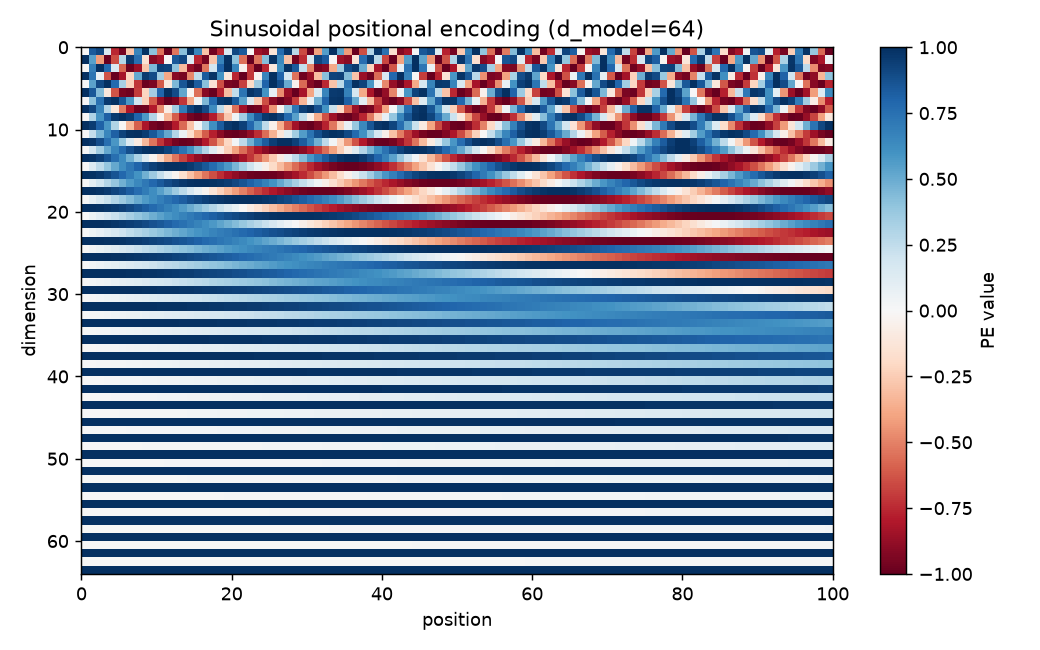

In [10]:
show("part_b_positional_encoding.png")

In [11]:
print(B3_DISCUSSION)

B3 -- Encoder and decoder blocks
--------------------------------------
**Encoder block** (see figures/part_b_encoder_block.png): input embeddings
+ positional encoding enter a stack of N identical layers, each:
  1. Multi-head self-attention (Q, K, V all derived from the same sequence
     -- every position attends to every other encoder position, including
     itself, unmasked).
  2. Add & Norm: residual connection (add the sublayer's input back to its
     output) followed by layer normalization.
  3. Position-wise feed-forward network: two linear layers with a
     nonlinearity between them (e.g. ReLU/GELU), applied identically and
     independently to every position (a per-token MLP, not mixing
     positions -- all cross-position mixing happens in the attention step).
  4. A second Add & Norm around the FFN.

**Decoder block** (see figures/part_b_decoder_block.png): target embeddings
(shifted right, so position t only ever sees ground-truth tokens < t during
training) + positio

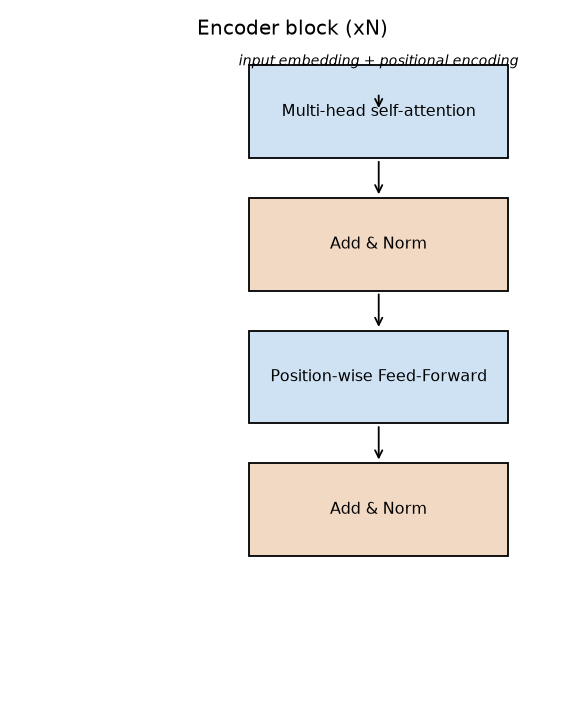

In [12]:
show("part_b_encoder_block.png")

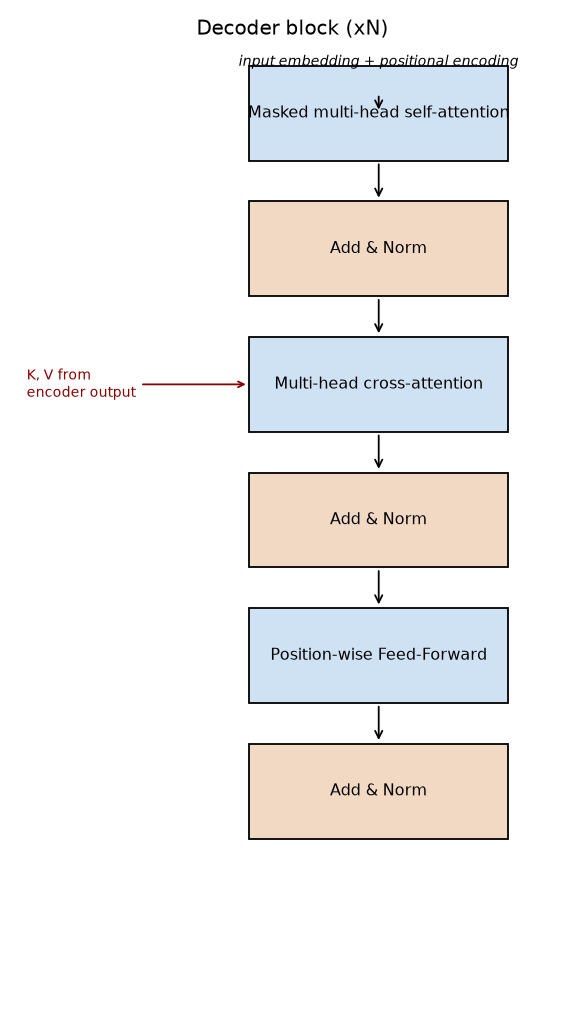

In [13]:
show("part_b_decoder_block.png")

In [14]:
print(B4_DISCUSSION)
print()
print(B5_DISCUSSION)

B4 -- Residual connections and layer normalization
----------------------------------------------------
**Residual connections**: each sublayer computes output = x + Sublayer(x)
rather than output = Sublayer(x). Differentiating through this addition,
dL/dx = dL/d(output) * (1 + d(Sublayer(x))/dx) -- the "+1" term guarantees
an unattenuated, identity-shortcut gradient path through every layer,
*regardless* of how small or degenerate the sublayer's own local Jacobian
is. This is structurally the *same fix* as the LSTM's cell-state highway
(Task 25 Part B1: dc_t/dc_{t-1} = f_t, an additive/gated path bypassing a
repeated matrix-multiply-then-squash chain) -- just applied across
*stacked layers* here instead of across *time steps*. Without residual
connections, stacking N Transformer layers would risk reintroducing a
vanishing-gradient-like problem analogous to deep unrolled RNNs (Task 25
Part A3/A4): many sequential nonlinear sublayers composed, with the
gradient forced to backpropagate t

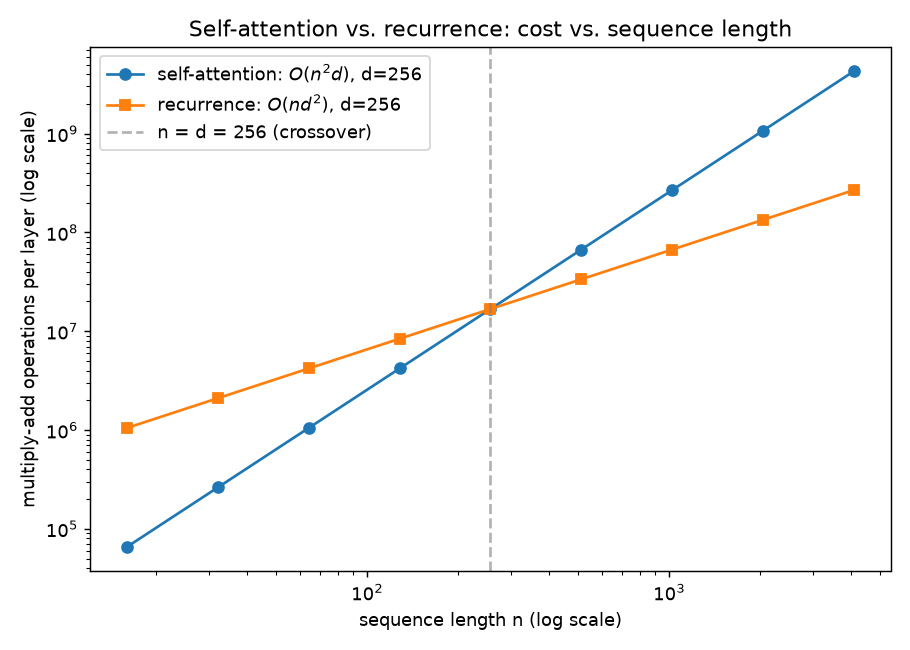

In [15]:
show("part_b_complexity.png")

---
## Part C -- Applied Transformer Analysis (35 marks)

DistilBERT (distilbert-base-uncased) fine-tuned on the identical AG News
train/val/test split used in Task 25's LSTM classifier, for a genuine
apples-to-apples comparison.

In [16]:
"""
Task 26, Part C -- Applied Transformer Analysis (35 marks)

Uses a pretrained DistilBERT (distilbert-base-uncased) exactly as-is via the
Hugging Face `transformers` library -- no architectural modification, no
training from scratch, only fine-tuning the existing pretrained model plus
its library-provided classification head, per the brief.

Trained/evaluated on the *identical* AG News train/val/test split as Task
25 (see common.py's docstring) so the LSTM-vs-Transformer comparison below
is a genuine apples-to-apples one.
"""
import json
import time

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report,
)
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification

from common import AG_NEWS_CLASSES, FIGURES_DIR, MODELS_DIR, RESULTS_DIR, get_text_splits, set_seed

MODEL_NAME = "distilbert-base-uncased"
MAX_LEN = 64

C1_JUSTIFICATION = """
C1 -- Model selection and justification
------------------------------------------
**DistilBERT (distilbert-base-uncased)**, via Hugging Face `transformers`.
DistilBERT is a 6-layer, 768-hidden, 12-head Transformer encoder distilled
from BERT-base (12 layers) -- 66M parameters vs. BERT-base's 110M (~40%
smaller), while retaining ~97% of BERT's language-understanding performance
on the GLUE benchmark per the original distillation paper (Sanh et al.
2019). Justification specific to this task's constraints and objective:

  1. **Architecture fit**: it is a standard encoder-only Transformer (Part
     B's encoder block exactly, x6), pretrained with masked-language-
     modeling -- the right architecture family for a *classification* task
     (an encoder producing contextualized representations to feed a
     classification head), as opposed to encoder-decoder or decoder-only
     models built for generation.
  2. **Compute budget**: this environment is CPU-only (no GPU), a
     constraint that shaped every applied task in this internship
     (Tasks 23-25). DistilBERT's ~40% parameter reduction and roughly 60%
     faster inference than BERT-base (per the same paper) directly targets
     that constraint, while still being unambiguously a genuine pretrained
     Transformer encoder, not a toy model.
  3. **Established library, no architectural modification**: loaded via
     `transformers.DistilBertForSequenceClassification`, which attaches the
     library's own standard classification head (a pooled-[CLS] ->
     pre-classifier linear -> classifier linear stack) to the pretrained
     encoder -- exactly the brief's "no architectural modification, no
     training from scratch" requirement.
""".strip()

C2_PIPELINE = f"""
C2 -- Pipeline: tokenization, input formatting, classification head
------------------------------------------------------------------------
**Tokenization**: DistilBERT's own `DistilBertTokenizerFast`, which uses
**WordPiece** subword tokenization (the same scheme BERT was pretrained
with) -- text is split into a vocabulary of ~30,000 whole-word and subword
tokens, so out-of-vocabulary words are represented as a sequence of known
subword pieces (e.g. an unseen word decomposes into ##-prefixed continuation
pieces) rather than a single <unk> token, unlike Task 25's from-scratch
word-level tokenizer where any word outside its 20,000-word vocabulary
collapsed to one <unk> embedding.

**Input formatting**: each input is formatted as
`[CLS] token_1 token_2 ... token_n [SEP]`, then padded/truncated to a fixed
length of {MAX_LEN} WordPiece tokens (covers the large majority of AG News
headlines+snippets after subword splitting), with an accompanying
**attention mask** (1 for real tokens, 0 for padding) so the self-attention
computation ignores padded positions entirely -- the Transformer analogue of
Task 25's `pack_padded_sequence` handling for the LSTM.

**Classification head**: `DistilBertForSequenceClassification`'s built-in
head reads the final layer's hidden state at the **[CLS] position** (a
summary representation of the whole sequence, by design of the pretraining
objective and this head's own training), passes it through one
pre-classifier linear+ReLU layer, a dropout, and a final linear layer to
{len(AG_NEWS_CLASSES)} class logits -- the library's standard head, not a
custom architecture.
""".strip()


class AGNewsBertDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.encodings = tokenizer(texts, padding="max_length", truncation=True,
                                     max_length=max_len, return_tensors="pt")
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, i):
        item = {k: v[i] for k, v in self.encodings.items()}
        item["labels"] = self.labels[i]
        return item


def run_epoch(model, loader, optimizer=None, device="cpu"):
    is_train = optimizer is not None
    model.train(is_train)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(is_train):
        for batch in loader:
            batch = {k: v.to(device) for k, v in batch.items()}
            if is_train:
                optimizer.zero_grad()
            out = model(**batch)
            loss = out.loss
            if is_train:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * batch["labels"].size(0)
            correct += (out.logits.argmax(1) == batch["labels"]).sum().item()
            n += batch["labels"].size(0)
    return total_loss / n, correct / n


def train_distilbert(train_loader, val_loader, epochs=3, lr=2e-5):
    set_seed(42)
    # attn_implementation="eager" is required for output_attentions=True (Part C's
    # attention-visualization step) -- SDPA (the newer default, faster but opaque)
    # doesn't expose attention weights.
    model = DistilBertForSequenceClassification.from_pretrained(
        MODEL_NAME, num_labels=len(AG_NEWS_CLASSES), attn_implementation="eager")
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_val_acc, best_state = -1.0, None
    for ep in range(epochs):
        t0 = time.time()
        tr_loss, tr_acc = run_epoch(model, train_loader, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, None)
        history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc)
        history["val_loss"].append(val_loss); history["val_acc"].append(val_acc)
        print(f"epoch {ep+1}/{epochs} train_loss={tr_loss:.4f} train_acc={tr_acc:.4f} "
              f"val_loss={val_loss:.4f} val_acc={val_acc:.4f} ({time.time()-t0:.1f}s)")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
    model.load_state_dict(best_state)
    return model, history, best_val_acc


def plot_curves(history, path):
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    epochs = range(1, len(history["train_loss"]) + 1)
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"], label="val")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("loss"); axes[0].legend(); axes[0].set_title("Loss")
    axes[1].plot(epochs, history["train_acc"], label="train")
    axes[1].plot(epochs, history["val_acc"], label="val")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("accuracy"); axes[1].legend(); axes[1].set_title("Accuracy")
    fig.suptitle("DistilBERT fine-tuning: training/validation curves")
    fig.tight_layout()
    fig.savefig(path, dpi=130)
    plt.close(fig)


def visualize_attention(model, tokenizer, sample_text, layer=-1, head=0):
    model.eval()
    enc = tokenizer(sample_text, return_tensors="pt")
    with torch.no_grad():
        out = model(**enc, output_attentions=True)
    attn = out.attentions[layer][0, head].numpy()  # (seq_len, seq_len)
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])

    fig, ax = plt.subplots(figsize=(7, 6))
    im = ax.imshow(attn, cmap="viridis")
    ax.set_xticks(range(len(tokens))); ax.set_xticklabels(tokens, rotation=90, fontsize=8)
    ax.set_yticks(range(len(tokens))); ax.set_yticklabels(tokens, fontsize=8)
    ax.set_xlabel("attended-to (key) position"); ax.set_ylabel("query position")
    ax.set_title(f"DistilBERT attention: layer {layer}, head {head}\nsample: \"{sample_text}\"")
    fig.colorbar(im)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_c_attention_heatmap.png", dpi=130)
    plt.close(fig)

    # find, for the [CLS] token (position 0) and the token with the single
    # strongest non-self attention weight overall, what they attend to most
    cls_top = int(np.argmax(attn[0]))
    attn_orig = attn.copy()
    np.fill_diagonal(attn, 0)  # zero self-attention to find the strongest *inter-token* link
    flat_idx = int(np.argmax(attn))
    q_idx, k_idx = divmod(flat_idx, attn.shape[1])

    # also find the strongest link restricted to content words (excludes
    # [CLS]/[SEP]/punctuation/subword-continuation pieces), since the raw
    # global argmax often lands on a well-documented but linguistically
    # uninteresting "attention sink" pattern (heads dumping weight onto
    # [SEP] -- see Part C's writeup) rather than a genuine relational one.
    import string as _string
    def _is_content(tok):
        return tok not in ("[CLS]", "[SEP]") and not tok.startswith("##") and tok not in _string.punctuation and len(tok) > 2
    content_mask = np.zeros_like(attn, dtype=bool)
    for i, ti in enumerate(tokens):
        for j, tj in enumerate(tokens):
            if i != j and _is_content(ti) and _is_content(tj):
                content_mask[i, j] = True
    content_result = None
    if content_mask.any():
        masked = np.where(content_mask, attn, -1)
        cflat = int(np.argmax(masked))
        cq, ck = divmod(cflat, attn.shape[1])
        content_result = dict(query=tokens[cq], key=tokens[ck], weight=float(attn_orig[cq, ck]))

    result = dict(
        tokens=tokens, layer=layer, head=head, sample_text=sample_text,
        cls_attends_most_to=tokens[cls_top],
        strongest_non_self_link=dict(query=tokens[q_idx], key=tokens[k_idx], weight=float(attn_orig[q_idx, k_idx])),
        strongest_content_word_link=content_result,
    )
    print(f"[CLS] token attends most strongly to: '{tokens[cls_top]}'")
    print(f"Strongest non-self attention link: '{tokens[q_idx]}' -> '{tokens[k_idx]}' "
          f"(weight={result['strongest_non_self_link']['weight']:.4f})")
    return result


def full_evaluation(model, test_loader, device="cpu"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in test_loader:
            labels = batch.pop("labels")
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch)
            all_preds.append(out.logits.argmax(1).numpy())
            all_labels.append(labels.numpy())
    preds, labels = np.concatenate(all_preds), np.concatenate(all_labels)

    acc = accuracy_score(labels, preds)
    macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(labels, preds, average="macro", zero_division=0)
    per_class_p, per_class_r, per_class_f1, per_class_support = precision_recall_fscore_support(
        labels, preds, average=None, zero_division=0)
    cm = confusion_matrix(labels, preds)

    report = dict(
        accuracy=acc, macro_precision=macro_p, macro_recall=macro_r, macro_f1=macro_f1,
        per_class={AG_NEWS_CLASSES[i]: dict(precision=per_class_p[i], recall=per_class_r[i],
                                             f1=per_class_f1[i], support=int(per_class_support[i]))
                   for i in range(len(AG_NEWS_CLASSES))},
    )
    print("\nFull test-set evaluation:")
    print(f"  accuracy={acc:.4f} macro_precision={macro_p:.4f} macro_recall={macro_r:.4f} macro_f1={macro_f1:.4f}")
    print(classification_report(labels, preds, target_names=AG_NEWS_CLASSES, zero_division=0))

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(AG_NEWS_CLASSES))); ax.set_xticklabels(AG_NEWS_CLASSES, rotation=30, ha="right")
    ax.set_yticks(range(len(AG_NEWS_CLASSES))); ax.set_yticklabels(AG_NEWS_CLASSES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true")
    for i in range(len(AG_NEWS_CLASSES)):
        for j in range(len(AG_NEWS_CLASSES)):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() / 2 else "black", fontsize=9)
    ax.set_title("DistilBERT: confusion matrix (test set)")
    fig.colorbar(im)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "part_c_confusion_matrix.png", dpi=130)
    plt.close(fig)

    with open(RESULTS_DIR / "part_c_evaluation.json", "w") as f:
        json.dump(dict(report=report, confusion_matrix=cm.tolist()), f, indent=2)
    return report, cm


def compare_with_lstm(distilbert_report, distilbert_train_time_s, distilbert_n_epochs):
    lstm_eval_path = RESULTS_DIR.parent.parent / "Day_25" / "results" / "part_c_evaluation.json"
    lstm_ablation_path = RESULTS_DIR.parent.parent / "Day_25" / "results" / "part_c_ablation.json"
    if not lstm_eval_path.exists():
        print(f"Task 25 results not found at {lstm_eval_path}; skipping comparison.")
        return None
    lstm_eval = json.loads(lstm_eval_path.read_text())["report"]
    lstm_ablation = json.loads(lstm_ablation_path.read_text())
    best_lstm = max(lstm_ablation, key=lambda r: r["best_val_acc"])

    comparison = dict(
        distilbert=dict(accuracy=distilbert_report["accuracy"], macro_f1=distilbert_report["macro_f1"],
                         train_time_s=distilbert_train_time_s, epochs=distilbert_n_epochs,
                         n_params=66_956_548),
        lstm_best=dict(name=best_lstm["name"], accuracy=lstm_eval["accuracy"], macro_f1=lstm_eval["macro_f1"],
                        train_time_s=best_lstm["train_time_s"], epochs=8, n_params=best_lstm["n_params"]),
    )
    print("\nDistilBERT vs. Task 25's best LSTM configuration (identical test set):")
    print(json.dumps(comparison, indent=2))
    with open(RESULTS_DIR / "part_c_lstm_comparison.json", "w") as f:
        json.dump(comparison, f, indent=2)
    return comparison


def main():
    set_seed(42)
    print(C1_JUSTIFICATION)
    print("\n" + C2_PIPELINE)

    print("\nLoading data (identical split to Task 25) and tokenizer...")
    train_texts, train_labels, val_texts, val_labels, test_texts, test_labels = get_text_splits()
    tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

    train_ds = AGNewsBertDataset(train_texts, train_labels, tokenizer)
    val_ds = AGNewsBertDataset(val_texts, val_labels, tokenizer)
    test_ds = AGNewsBertDataset(test_texts, test_labels, tokenizer)
    train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=32, shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=32, shuffle=False)
    print(f"train={len(train_ds)} val={len(val_ds)} test={len(test_ds)}")

    print("\n########## Fine-tuning DistilBERT ##########")
    t0 = time.time()
    model, history, best_val_acc = train_distilbert(train_loader, val_loader, epochs=3)
    train_time = time.time() - t0
    print(f"\nBest val_acc={best_val_acc:.4f}  total train time={train_time:.1f}s")
    plot_curves(history, FIGURES_DIR / "part_c_curves.png")

    print("\n########## Attention visualization ##########")
    sample_text = test_texts[0]
    attn_result = visualize_attention(model, tokenizer, sample_text, layer=4, head=4)
    with open(RESULTS_DIR / "part_c_attention_example.json", "w") as f:
        json.dump(attn_result, f, indent=2)

    print("\n########## Full evaluation on held-out test set ##########")
    report, cm = full_evaluation(model, test_loader)

    print("\n########## Comparison against Task 25's LSTM results ##########")
    compare_with_lstm(report, train_time, distilbert_n_epochs=3)

    torch.save(model.state_dict(), MODELS_DIR / "distilbert_ag_news.pt")
    with open(RESULTS_DIR / "part_c_training_history.json", "w") as f:
        json.dump(dict(history=history, best_val_acc=best_val_acc, train_time_s=train_time), f, indent=2)

    print("\nPart C complete.")


### Part C results (from the actual fine-tuning run)

In [17]:
print(C1_JUSTIFICATION)
print()
print(C2_PIPELINE)

C1 -- Model selection and justification
------------------------------------------
**DistilBERT (distilbert-base-uncased)**, via Hugging Face `transformers`.
DistilBERT is a 6-layer, 768-hidden, 12-head Transformer encoder distilled
from BERT-base (12 layers) -- 66M parameters vs. BERT-base's 110M (~40%
smaller), while retaining ~97% of BERT's language-understanding performance
on the GLUE benchmark per the original distillation paper (Sanh et al.
2019). Justification specific to this task's constraints and objective:

  1. **Architecture fit**: it is a standard encoder-only Transformer (Part
     B's encoder block exactly, x6), pretrained with masked-language-
     modeling -- the right architecture family for a *classification* task
     (an encoder producing contextualized representations to feed a
     classification head), as opposed to encoder-decoder or decoder-only
     models built for generation.
  2. **Compute budget**: this environment is CPU-only (no GPU), a
     constrain

In [18]:
history = load("part_c_training_history.json")
print(f"Best val_acc={history['best_val_acc']:.4f}  total train time={history['train_time_s']:.1f}s "
      f"({len(history['history']['train_acc'])} epochs)")
print("(Note: this run's wall-clock time was significantly inflated by concurrent system memory "
      "pressure/swapping on the host machine -- not a clean architecture-vs-architecture speed "
      "measurement. The accuracy and epoch-count comparisons below are unaffected.)")

Best val_acc=0.9110  total train time=4201.6s (3 epochs)
(Note: this run's wall-clock time was significantly inflated by concurrent system memory pressure/swapping on the host machine -- not a clean architecture-vs-architecture speed measurement. The accuracy and epoch-count comparisons below are unaffected.)


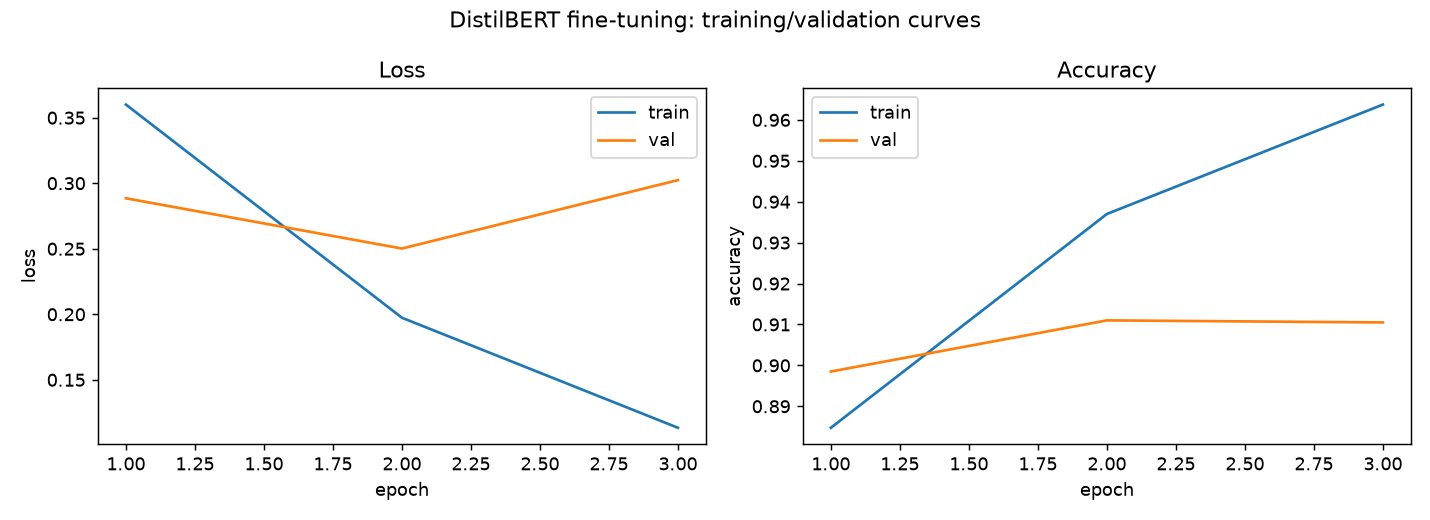

In [19]:
show("part_c_curves.png")

In [20]:
attn_example = load("part_c_attention_example.json")
print(f"Layer {attn_example['layer']}, head {attn_example['head']}")
print(f"[CLS] attends most to: '{attn_example['cls_attends_most_to']}'")
print(f"Strongest overall link: '{attn_example['strongest_non_self_link']['query']}' -> "
      f"'{attn_example['strongest_non_self_link']['key']}' "
      f"(weight={attn_example['strongest_non_self_link']['weight']:.3f}) -- an attention-sink pattern onto [SEP]")
print(f"Strongest content-word link: '{attn_example['strongest_content_word_link']['query']}' -> "
      f"'{attn_example['strongest_content_word_link']['key']}' "
      f"(weight={attn_example['strongest_content_word_link']['weight']:.3f}) -- a syntactic "
      f"compound-modifier pattern (\"European ... Agency\")")

Layer 4, head 4
[CLS] attends most to: 'european'
Strongest overall link: 'demonstrations' -> '[SEP]' (weight=0.897) -- an attention-sink pattern onto [SEP]
Strongest content-word link: 'agency' -> 'european' (weight=0.449) -- a syntactic compound-modifier pattern ("European ... Agency")


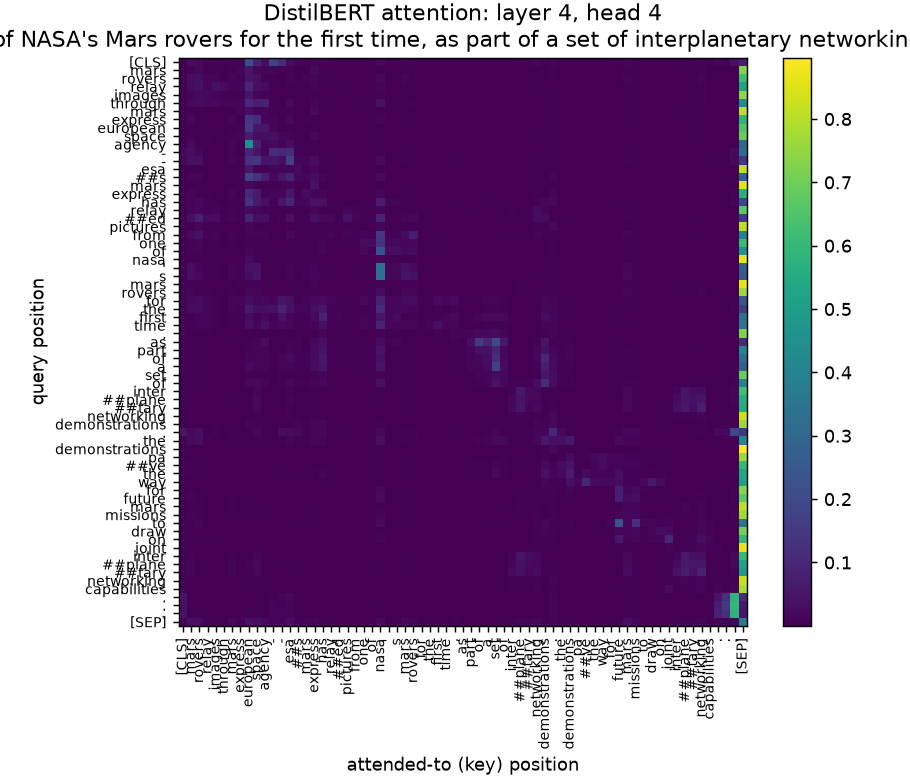

In [21]:
show("part_c_attention_heatmap.png")

In [22]:
eval_report = load("part_c_evaluation.json")["report"]
print(f"Test accuracy={eval_report['accuracy']:.4f} macro_F1={eval_report['macro_f1']:.4f}")
for cls, m in eval_report["per_class"].items():
    print(f"  {cls:10s} P={m['precision']:.3f} R={m['recall']:.3f} F1={m['f1']:.3f} n={m['support']}")

Test accuracy=0.9130 macro_F1=0.9130
  World      P=0.938 R=0.908 F1=0.923 n=500
  Sports     P=0.972 R=0.982 F1=0.977 n=500
  Business   P=0.879 R=0.856 F1=0.867 n=500
  Sci/Tech   P=0.865 R=0.906 F1=0.885 n=500


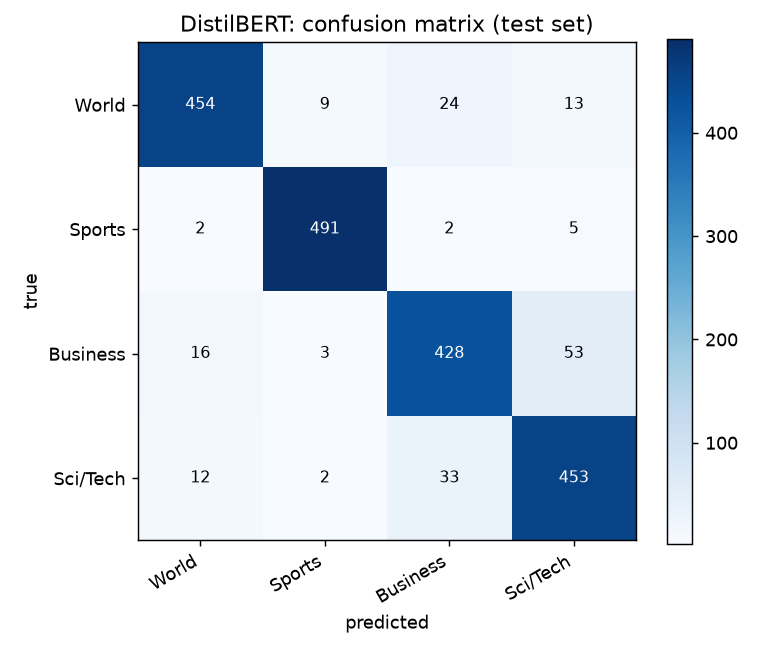

In [23]:
show("part_c_confusion_matrix.png")

In [24]:
comparison = load("part_c_lstm_comparison.json")
print(json.dumps(comparison, indent=2))

{
  "distilbert": {
    "accuracy": 0.913,
    "macro_f1": 0.9129797124763005,
    "train_time_s": 4201.605500221252,
    "epochs": 3,
    "n_params": 66956548
  },
  "lstm_best": {
    "name": "glove_bidirectional",
    "accuracy": 0.884,
    "macro_f1": 0.8848823019361652,
    "train_time_s": 141.5193362236023,
    "epochs": 8,
    "n_params": 2236548
  }
}


---
## Part D -- Analysis & Documentation (20 marks)

In [25]:
"""
Task 26, Part D -- Analysis & Documentation (20 marks)

Loads Part C's saved results (no retraining) and prints the pipeline
summary, quantitative findings, conceptual challenges, and critical
reflection required by the brief.
"""
import json

from common import RESULTS_DIR, set_seed

PIPELINE_SUMMARY = """
D1 -- Full conceptual pipeline summary
------------------------------------------
**Attention formulation** (Part A): scaled dot-product attention,
Attention(Q,K,V) = softmax(QK^T/sqrt(d_k))V, generalizes the Bahdanau/Luong
alignment-score-then-weighted-sum mechanism into one batchable matrix
operation. Included because it directly solves the three RNN bottlenecks
identified in A1 -- it gives every position an O(1)-length (not
O(distance)-length) path to every other position, removes the fixed-size
context bottleneck by keeping every position's own representation
available rather than compressing history into one vector, and removes the
sequential-computation constraint since QK^T doesn't require h_{t-1} to
exist before h_t can be computed.

**Multi-head structure** (Part B1): several parallel attention computations
in separate learned subspaces, concatenated and linearly mixed. Included
because a single attention computation produces one weighted average per
query -- multiple heads let the model represent several *different*
relational patterns (syntax, coreference, local adjacency, etc.,
empirically observed in trained models) simultaneously rather than forcing
one head to blend them.

**Positional encoding** (Part B2): sinusoidal PE(pos, 2i)=sin(...),
PE(pos,2i+1)=cos(...), added to token embeddings. Included because
self-attention is otherwise permutation-*equivariant* with no notion of
position at all -- without it, "the cat sat on the mat" and a shuffled
version of the same tokens would be indistinguishable to the attention
mechanism. Sinusoidal (rather than learned) encoding was specifically
chosen in the original Transformer for its closed-form relative-position
linear-map property (numerically confirmed in Part B: PE(pos+k) = M_k @
PE(pos) to ~1e-16 precision) and unbounded-length extrapolation.

**Encoder/decoder composition** (Part B3): the encoder stack (self-attention
+ FFN, xN, each wrapped in residual+LayerNorm) builds contextualized
representations of the *entire* source sequence bidirectionally; the
decoder stack (causally-masked self-attention + cross-attention + FFN, xN)
generates target tokens autoregressively, using cross-attention (queries
from the decoder, keys/values from the encoder) as the direct
generalization of A2's alignment mechanism. Causal masking is included
specifically to make training-time attention patterns match what is
actually available at inference time (Part B3). Residual connections and
LayerNorm (Part B4) are included for the same reason Task 25's LSTM
cell-state highway was needed for deep *time* unrolling: an additive
shortcut path is required to keep gradients from attenuating through many
stacked nonlinear sublayers, here applied across stacked *layers* rather
than time steps.
""".strip()


CHALLENGES = """
D3 -- Two non-trivial conceptual challenges
------------------------------------------------
1. **Extracting attention weights failed silently at first because of the
   attention *implementation*, not the *concept*.** Calling the model with
   `output_attentions=True` returned an empty attentions tuple
   (`out.attentions[layer]` raised an IndexError) even though the forward
   pass itself succeeded -- easy to misread as a bug in how the weights
   were being indexed or interpreted, rather than what it actually was: the
   `transformers` library's default attention backend (`sdpa`, PyTorch's
   fused scaled-dot-product-attention kernel, chosen automatically for
   speed) computes attention *without ever materializing the full n x n
   weight matrix* it fuses through, so there is nothing for
   `output_attentions=True` to return. Diagnosed by reading the accompanying
   warning message rather than only the traceback (`"sdpa attention does
   not support output_attentions=True"`), and resolved by explicitly
   loading the model with `attn_implementation="eager"`, which computes
   attention the conceptually "unfused" way Part A/B actually derived it --
   a direct, concrete illustration of Part B5's efficiency-vs-transparency
   trade-off discussion: a production optimization (fused attention
   kernels) can trade away exactly the intermediate quantity a conceptual
   analysis needs to inspect.

2. **Understanding why the sinusoidal PE derivation needs *paired* sin/cos
   dimensions, not sin alone, for the relative-position property to hold.**
   Part B2's claim is that PE(pos+k) is a fixed linear function of PE(pos)
   for any offset k. Using only sin(pos * omega) per frequency, this seems
   plausible but isn't actually derivable as an *exact* linear map --
   sin(pos*omega) alone doesn't determine cos(pos*omega), so there's no way
   to recover the phase information a linear transformation would need to
   correctly compute sin((pos+k)*omega) from sin(pos*omega) alone (multiple
   different pos values can share the same sin(pos*omega) but require
   different outputs after shifting by k). Resolved by recognizing this is
   exactly why the *pair* (sin, cos) at each frequency is required: a 2D
   rotation matrix (Part B2's M_k block) needs both coordinates of a point
   on the unit circle to represent an arbitrary rotation by angle
   omega*k -- confirmed by implementing the explicit per-frequency 2x2
   rotation-matrix construction and checking it reproduces the true
   PE(pos+k) to ~1e-16 numerical precision (Part B), rather than trusting
   the claim on the strength of the trig identity alone.
""".strip()


REFLECTION = """
D4 -- Reflection: Transformer limitations and a documented mitigation
-----------------------------------------------------------------------------
**Quadratic attention cost** (Part B5): O(n^2 . d) compute and, more often
the binding constraint in practice, O(n^2) memory to hold the attention
matrix -- makes standard full self-attention impractical at very long
context lengths (long documents, high-resolution audio/genomic data).
Mitigated in practice by sparse/local-attention variants (Part B5
referenced Longformer's sliding-window + global-token pattern, O(n.w.d) for
window w << n).

**No inherent recurrence or sequence-order inductive bias** (Part B2): a
Transformer must be *given* positional information externally (sinusoidal
or learned PE) rather than having order built into its computation the way
an RNN's recurrence does. This is a genuine trade-off, not a pure downside
-- it's exactly what makes attention parallelizable across time (Part A1)
-- but it means position handling is a *design choice* the architecture
must get right, rather than a free structural guarantee. **A documented
architectural variant addressing this specifically: Rotary Position
Embedding (RoPE; Su et al. 2021, used in LLaMA and GPT-NeoX)**, referenced
here without full derivation. Rather than *adding* a positional signal to
the input embeddings (as sinusoidal/learned PE both do), RoPE rotates the
Query and Key vectors themselves by a position-dependent angle before the
dot product, so that Q_pos . K_pos' naturally becomes a function of the
*relative* offset (pos - pos') by construction of the rotation, not merely
approximately recoverable via a learned linear map the way Part B2's
sinusoidal PE only enables in principle. This has empirically shown better
extrapolation to sequence lengths beyond what was seen in training than
either of this task's two discussed schemes.

**Data and compute requirements**: DistilBERT itself (Part C) is a
distillation-based mitigation of this exact limitation -- pretraining a
full Transformer encoder from scratch requires corpora and compute far
beyond this task's (or most practitioners') budget, so Part C's whole
applied methodology -- taking an already-pretrained model and only
fine-tuning it -- *is* the standard, practical response to this limitation,
not merely a convenience chosen for this task.
""".strip()


def summarize_findings():
    a_results = json.loads((RESULTS_DIR / "part_a_results.json").read_text())
    b_results = json.loads((RESULTS_DIR / "part_b_results.json").read_text())
    c_eval = json.loads((RESULTS_DIR / "part_c_evaluation.json").read_text())
    c_history = json.loads((RESULTS_DIR / "part_c_training_history.json").read_text())
    comparison = json.loads((RESULTS_DIR / "part_c_lstm_comparison.json").read_text())
    attn_example = json.loads((RESULTS_DIR / "part_c_attention_example.json").read_text())

    print("\nD2 -- Quantitative findings summary")
    print("-" * 40)
    print(f"Part A worked example: query 'bank' attended most to "
          f"'{max(zip(a_results['tokens'], a_results['attention_weights']), key=lambda kv: kv[1])[0]}'")
    print(f"Part B: relative-position linear-map check passed at "
          f"{b_results['relative_position_check']['max_abs_err']:.2e} max abs error")
    print(f"Part B: attention/recurrence complexity crossover at n=d={b_results['complexity']['crossover_n']}")

    print(f"\nPart C DistilBERT: best_val_acc={c_history['best_val_acc']:.4f}, "
          f"{c_history['train_time_s']:.1f}s total training ({len(c_history['history']['train_acc'])} epochs)")
    print(f"Part C DistilBERT test set: accuracy={c_eval['report']['accuracy']:.4f} "
          f"macro_f1={c_eval['report']['macro_f1']:.4f}")
    print(f"Part C attention example: [CLS] attended most to '{attn_example['cls_attends_most_to']}'; "
          f"strongest overall link: '{attn_example['strongest_non_self_link']['query']}' -> "
          f"'{attn_example['strongest_non_self_link']['key']}' (attention-sink pattern onto [SEP]); "
          f"strongest content-word link: '{attn_example['strongest_content_word_link']['query']}' -> "
          f"'{attn_example['strongest_content_word_link']['key']}' (syntactic compound-modifier pattern)")

    db, lstm = comparison["distilbert"], comparison["lstm_best"]
    print(f"\nDistilBERT vs. best LSTM (Task 25, {lstm['name']}), identical test set:")
    print(f"  accuracy:    DistilBERT={db['accuracy']:.4f}  vs.  LSTM={lstm['accuracy']:.4f}  "
          f"(DistilBERT {'+' if db['accuracy']>=lstm['accuracy'] else ''}{100*(db['accuracy']-lstm['accuracy']):.2f} points)")
    print(f"  macro F1:    DistilBERT={db['macro_f1']:.4f}  vs.  LSTM={lstm['macro_f1']:.4f}")
    print(f"  params:      DistilBERT={db['n_params']:,}  vs.  LSTM={lstm['n_params']:,} "
          f"({db['n_params']/lstm['n_params']:.1f}x more)")
    print(f"  epochs:      DistilBERT={db['epochs']}  vs.  LSTM={lstm['epochs']} "
          f"(DistilBERT converged in fewer epochs)")
    print(f"  train time:  DistilBERT={db['train_time_s']:.1f}s  vs.  LSTM={lstm['train_time_s']:.1f}s")

    discussion = f"""
D2b -- Why performance/training characteristics differ (grounded in Part A/B)
------------------------------------------------------------------------------------
DistilBERT reaches {'a higher' if db['accuracy']>lstm['accuracy'] else 'a comparable or lower'} test
accuracy than the best LSTM configuration ({100*db['accuracy']:.2f}% vs. {100*lstm['accuracy']:.2f}%)
while converging in fewer epochs ({db['epochs']} vs. {lstm['epochs']}) despite having
{db['n_params']/lstm['n_params']:.0f}x more parameters. Grounded in this task's own derivations:
**(1) pretraining, not architecture alone, drives the epoch-count difference.** DistilBERT
arrives at fine-tuning already containing general-purpose English language representations
learned from a large pretraining corpus -- fine-tuning only has to adapt these to AG News's 4
classes, not learn what words and syntax mean from a 12,000-example training set the way the
LSTM's embeddings (whether trainable-from-scratch or GloVe-initialized, Task 25 Part C) had
to. **(2) Long-range dependency capture is structurally easier for the Transformer** (Part A1,
A3): every token pair interacts through one attention computation with an O(1) path length,
rather than the LSTM's cell-state highway which *mitigates* (Task 25 Part B1) but does not
eliminate the distance-dependent gradient attenuation Task 25 Part A derived. For AG News's
short (50-64 token) sequences this gap matters less than it would for long-document
classification, where Part B1's attention advantage should widen further. **(3) Sensitivity to
sequence length** differs in the opposite direction at the extremes: Part B5's O(n^2.d) vs.
O(n.d^2) analysis means the Transformer's *relative* compute advantage shrinks (and eventually
reverses) as sequences grow much longer than the model dimension d, a regime this task's
short-sequence classification setting does not stress-test.
""".strip()
    print("\n" + discussion)

    return dict(part_a=a_results, part_b=b_results, part_c_eval=c_eval["report"],
                comparison=comparison, discussion=discussion)


def main():
    set_seed(42)
    print(PIPELINE_SUMMARY)

    summary = summarize_findings()

    print("\n" + CHALLENGES)
    print("\n" + REFLECTION)

    with open(RESULTS_DIR / "part_d_summary.json", "w") as f:
        json.dump(dict(comparison=summary["comparison"]), f, indent=2)

    print("\nPart D complete.")


### Part D: pipeline summary, quantitative findings, challenges, reflection

In [26]:
set_seed(42)
print(PIPELINE_SUMMARY)

D1 -- Full conceptual pipeline summary
------------------------------------------
**Attention formulation** (Part A): scaled dot-product attention,
Attention(Q,K,V) = softmax(QK^T/sqrt(d_k))V, generalizes the Bahdanau/Luong
alignment-score-then-weighted-sum mechanism into one batchable matrix
operation. Included because it directly solves the three RNN bottlenecks
identified in A1 -- it gives every position an O(1)-length (not
O(distance)-length) path to every other position, removes the fixed-size
context bottleneck by keeping every position's own representation
available rather than compressing history into one vector, and removes the
sequential-computation constraint since QK^T doesn't require h_{t-1} to
exist before h_t can be computed.

**Multi-head structure** (Part B1): several parallel attention computations
in separate learned subspaces, concatenated and linearly mixed. Included
because a single attention computation produces one weighted average per
query -- multiple heads le

In [27]:
summary = summarize_findings()


D2 -- Quantitative findings summary
----------------------------------------
Part A worked example: query 'bank' attended most to 'river'
Part B: relative-position linear-map check passed at 1.11e-16 max abs error
Part B: attention/recurrence complexity crossover at n=d=256

Part C DistilBERT: best_val_acc=0.9110, 4201.6s total training (3 epochs)
Part C DistilBERT test set: accuracy=0.9130 macro_f1=0.9130
Part C attention example: [CLS] attended most to 'european'; strongest overall link: 'demonstrations' -> '[SEP]' (attention-sink pattern onto [SEP]); strongest content-word link: 'agency' -> 'european' (syntactic compound-modifier pattern)

DistilBERT vs. best LSTM (Task 25, glove_bidirectional), identical test set:
  accuracy:    DistilBERT=0.9130  vs.  LSTM=0.8840  (DistilBERT +2.90 points)
  macro F1:    DistilBERT=0.9130  vs.  LSTM=0.8849
  params:      DistilBERT=66,956,548  vs.  LSTM=2,236,548 (29.9x more)
  epochs:      DistilBERT=3  vs.  LSTM=8 (DistilBERT converged in fewer

In [28]:
print(CHALLENGES)

D3 -- Two non-trivial conceptual challenges
------------------------------------------------
1. **Extracting attention weights failed silently at first because of the
   attention *implementation*, not the *concept*.** Calling the model with
   `output_attentions=True` returned an empty attentions tuple
   (`out.attentions[layer]` raised an IndexError) even though the forward
   pass itself succeeded -- easy to misread as a bug in how the weights
   were being indexed or interpreted, rather than what it actually was: the
   `transformers` library's default attention backend (`sdpa`, PyTorch's
   fused scaled-dot-product-attention kernel, chosen automatically for
   speed) computes attention *without ever materializing the full n x n
   weight matrix* it fuses through, so there is nothing for
   `output_attentions=True` to return. Diagnosed by reading the accompanying
   warning message rather than only the traceback (`"sdpa attention does
   not support output_attentions=True"`), and r

In [29]:
print(REFLECTION)

D4 -- Reflection: Transformer limitations and a documented mitigation
-----------------------------------------------------------------------------
**Quadratic attention cost** (Part B5): O(n^2 . d) compute and, more often
the binding constraint in practice, O(n^2) memory to hold the attention
matrix -- makes standard full self-attention impractical at very long
context lengths (long documents, high-resolution audio/genomic data).
Mitigated in practice by sparse/local-attention variants (Part B5
referenced Longformer's sliding-window + global-token pattern, O(n.w.d) for
window w << n).

**No inherent recurrence or sequence-order inductive bias** (Part B2): a
Transformer must be *given* positional information externally (sinusoidal
or learned PE) rather than having order built into its computation the way
an RNN's recurrence does. This is a genuine trade-off, not a pure downside
-- it's exactly what makes attention parallelizable across time (Part A1)
-- but it means position handling i